In [20]:
from openai import OpenAI
import cv2, os, base64, time
from IPython.display import display, Image, Audio
from PIL import Image as Image_2
from io import BytesIO




In [24]:
file_path = '/Users/halukcemdemirhan/Downloads/albert_einstein_gpt4v.mp4'

client = OpenAI(api_key="sk-None-ZGidvjoLgxQrFdtRqA39T3BlbkFJNxWcz0E5lBw0cMg5GKTZ")
resized_width = 500
resized_height = 500

In [68]:
video = cv2.VideoCapture(file_path)
video

< cv2.VideoCapture 0x14de82cd0>

In [21]:
import cv2
print(cv2.__version__)


4.10.0


In [69]:
base64Frames = []
if not video.isOpened():
    print("Error: Video file could not be opened.")
while video.isOpened():
    ret, frame = video.read()
    if not ret:
        break
    _, buffer = cv2.imencode('.jpg', frame)
    base64Frames.append(base64.b64encode(buffer).decode('utf-8'))   

video.release()

In [70]:
len(base64Frames)

1228

In [71]:
nth_frame = 10
trimmed_frames = base64Frames[::nth_frame]



23.976023976023978

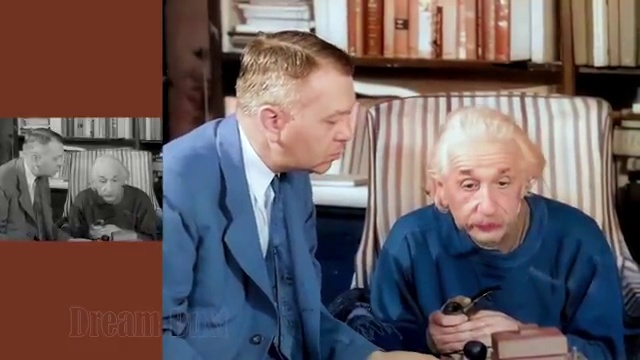

In [72]:
display_handle = display(None, display_id=True)
for img in trimmed_frames:
    display_handle.update(Image(data=base64.b64decode(img.encode("utf-8")), width=resized_width, height=resized_height))
    time.sleep(0.050 * nth_frame)

    

In [73]:
def resize_image(image, target_width, target_height):
    image_data = base64.b64decode(image.encode("utf-8"))
    image = Image_2.open(BytesIO(image_data))
    image = image.resize((target_width, target_height))
    buffered = BytesIO()
    image.save(buffered, format="JPEG")
    return base64.b64encode(buffered.getvalue()).decode('utf-8')

In [74]:
text_prompt = f"Here is the every nth frame (where n={nth_frame}) of the video file. Please describe the video."

In [60]:
text_prompt_entry = {"type:": "text", "content": text_prompt}

In [61]:
image_entries = [
    {
        "type" : "image_url",
        "image_url": {
            "url": f"data:image/jpeg;base64,{resize_image(frame, resized_width, resized_height)}"
        }
    } for frame in trimmed_frames
]

In [62]:
messages = [
    {
        "role": "user",
        "content": [text_prompt_entry] + image_entries
    }
]

In [65]:
params = {
    "model": "gpt-4o-mini",
    "messages": messages,
    "max_tokens": 1000,
}

In [77]:
result = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "user",
            "content": {
                "type": "text",
                "content": text_prompt
            }
        },
        *[
            {
                "role": "user",
                "content": {
                    "type": "image_url",
                    "image_url": f"data:image/jpeg;base64,{resize_image(frame, resized_width, resized_height)}"
                }
            } for frame in trimmed_frames
        ]
    ],
    max_tokens=1000
)

print(result.choices[0])


BadRequestError: Error code: 400 - {'error': {'message': "Invalid type for 'messages[0].content[0]': expected an object, but got a string instead.", 'type': 'invalid_request_error', 'param': 'messages[0].content[0]', 'code': 'invalid_type'}}

In [82]:
from openai import OpenAI
import os

# Initialise Open AI client
# Frames from previous example
base64Frames = []

message = [
    { "role": "user",
        "content": [
        "These are frames of a video. Can you describe what you can frame by frame? Do like frame 1: .. frmae 2... one line each. Should be short descriptions? ",
        *map(lambda x: {"image": x, "resize": 768}, trimmed_frames[0::20]), ],
    },
]
parameters = { "model": "gpt-4o", "messages": message, "max_tokens": 500 }

result = client.chat.completions.create(**parameters)
print(result.choices[0].message.content)


Frame 1: Three men at a table in a library, one holding a pipe.
Frame 2: Close-up of a man in a blue suit writing or examining something.
Frame 3: Close-up of another man with disheveled white hair in a blue sweater looking down.
Frame 4: The man in the blue suit converses with the man holding the pipe.
Frame 5: The man in the blue suit continues talking to the man with the pipe.
Frame 6: The conversation between the two men persists, with the white-haired man looking to the side.
Frame 7: The man in the blue suit leans in closely, observing the white-haired man focusing on the object in his hand.


In [3]:
import imageio
from moviepy.editor import VideoFileClip
import os

ffmpeg_path = imageio.plugins.ffmpeg.get_exe()
os.environ["IMAGEIO_FFMPEG_EXE"] = ffmpeg_path

import cv2
from pydub import AudioSegment

file_path = '/Users/halukcemdemirhan/Downloads/1v1_defending_video.mp4'

video = cv2.VideoCapture(file_path)

fps = video.get(cv2.CAP_PROP_FPS)

total_duration = int(video.get(cv2.CAP_PROP_FRAME_COUNT) / fps)

video_clip = VideoFileClip(file_path)
audio_path = "/tmp/temp_audio.wav"
video_clip.audio.write_audiofile(audio_path, codec='pcm_s16le')
full_audio = AudioSegment.from_wav(audio_path)

interval =   
current_time = 0
frame_count = 0

# List to store frames and audio segments
frames = []
audio_segments = []

while current_time < total_duration:
    video.set(cv2.CAP_PROP_POS_MSEC, current_time * 1000)
    
    ret, frame = video.read()
    if not ret:
        break
    
    frames.append(frame)
    
    start_time = current_time * 1000
    end_time = (current_time + interval) * 1000
    audio_segment = full_audio[start_time:end_time]
    audio_segments.append(audio_segment)
    
    current_time += interval
    frame_count += 1

video.release()

for i, (frame, audio_segment) in enumerate(zip(frames, audio_segments)):
    frame_file = f"frame_{i}.jpg"
    cv2.imwrite(frame_file, frame)
    
    audio_file = f"audio_segment_{i}.mp3"
    audio_segment.export(audio_file, format="mp3")

    print(f"Saved {frame_file} and {audio_file}")


MoviePy - Writing audio in /tmp/temp_audio.wav


MoviePy - Done.


Saved frame_0.jpg and audio_segment_0.mp3
Saved frame_1.jpg and audio_segment_1.mp3
Saved frame_2.jpg and audio_segment_2.mp3
Saved frame_3.jpg and audio_segment_3.mp3
Saved frame_4.jpg and audio_segment_4.mp3


In [16]:
import imageio
from moviepy.editor import VideoFileClip
import os
import cv2
from pydub import AudioSegment

ffmpeg_path = imageio.plugins.ffmpeg.get_exe()
os.environ["IMAGEIO_FFMPEG_EXE"] = ffmpeg_path

file_path = '/Users/halukcemdemirhan/Downloads/1v1_defending_video.mp4'

video = cv2.VideoCapture(file_path)

fps = video.get(cv2.CAP_PROP_FPS)

total_duration = int(video.get(cv2.CAP_PROP_FRAME_COUNT) / fps)

video_clip = VideoFileClip(file_path)
audio_path = "/tmp/temp_audio.wav"
video_clip.audio.write_audiofile(audio_path, codec='pcm_s16le')
full_audio = AudioSegment.from_wav(audio_path)


frame_interval = 0.5  
frames_per_segment = 6  


current_time = 0
frame_count = 0


frames = []
audio_segments = []

while current_time < total_duration:

    video.set(cv2.CAP_PROP_POS_MSEC, current_time * 1000)
    ret, frame = video.read()
    if not ret:
        break
    
    frames.append(frame)
    
    if len(frames) == frames_per_segment:
        start_time = max(0, current_time * 1000 - (frames_per_segment * frame_interval * 1000))
        end_time = current_time * 1000
        audio_segment = full_audio[start_time:end_time]
        audio_segments.append(audio_segment)
        
        segment_dir = f"segment_{len(audio_segments) - 1}"
        os.makedirs(segment_dir, exist_ok=True)
        
        for i, frame in enumerate(frames):
            frame_file = os.path.join(segment_dir, f"frame_{frame_count + i}.jpg")
            cv2.imwrite(frame_file, frame)
        
        audio_file = os.path.join(segment_dir, f"audio_segment_{len(audio_segments) - 1}.mp3")
        audio_segment.export(audio_file, format="mp3")
        
        print(f"Saved {frames_per_segment} frames and corresponding audio to {segment_dir}")
        
        frames = []
        frame_count += frames_per_segment
    
    current_time += frame_interval

video.release()


MoviePy - Writing audio in /tmp/temp_audio.wav


MoviePy - Done.


Saved 6 frames and corresponding audio to segment_0
Saved 6 frames and corresponding audio to segment_1
Saved 6 frames and corresponding audio to segment_2
Saved 6 frames and corresponding audio to segment_3
Saved 6 frames and corresponding audio to segment_4
Saved 6 frames and corresponding audio to segment_5


In [18]:
from openai import OpenAI

file_list = []
for i in range(6):
  audio_file= open(f"segment_{i}/audio_segment_{i}.mp3", "rb")
  transcription = client.audio.transcriptions.create(
    model="whisper-1", 
    file=audio_file
  )
  file_list.append(transcription.text)

file_list




['to the left. So the first thing that we need to do is a.',
 "get pressure on the ball. So when we're coming out to we don't just want to come like this.",
 "If we do this, what are you going to do? Boom, he's gone.",
 'all right and he can even beat us like that first thing',
 'When we get out there, we sprint out.',
 'and then we get set. And set is something like this.']

In [21]:
for segment_idx, transcript in enumerate(file_list):
    segment_dir = f'segment_{segment_idx}'
    
    frame_files = sorted(
        [os.path.join(segment_dir, f) for f in os.listdir(segment_dir) if f.startswith('frame_')]
    )
    
    base64Frames = []
    for frame_file in frame_files:
        with open(frame_file, 'rb') as image_file:
            base64Frames.append(base64.b64encode(image_file.read()).decode('utf-8'))
    
    message = [
        {
            "role": "user",
            "content": [
                f"{transcript} Please describe the frames of this segment." + apis + transcrpt,
                *[
                    {"image": base64Frame, "resize": 768}
                    for base64Frame in base64Frames
                ],
            ],
        },
    ]
    
    parameters = {"model": "gpt-4o", "messages": message, "max_tokens": 500}

    result = client.chat.completions.create(**parameters)
    
    print(f"Segment {segment_idx} description:")
    print(result.choices[0].message.content)
    print("\n" + "="*50 + "\n")

Segment 0 description:
In this sequence of frames, two individuals are on a soccer field. The person on the right, wearing a dark top and shorts with bright green shoes, stands still with a soccer ball at their feet. Meanwhile, the individual on the left, wearing a white shirt, black pants, and blue shoes, is initially extending their right arm and then lowers it gradually. The setting includes an outdoor football (soccer) field with a green artificial turf, bordered by fencing, with buildings visible in the background.

In the last frame, text appears at the bottom reading, "1. Get pressure on the ball," indicating a soccer coaching point.

Overall, the frames depict an instructional or training moment in a soccer context, with one person likely explaining or demonstrating something to the other.


Segment 1 description:
The frames showcase a soccer drill or instruction segment on how to apply pressure on the ball in a game setting. The frames are as follows:

1. **First frame**: Two 

In [27]:
import imageio
from moviepy.editor import VideoFileClip
import os
import cv2
from pydub import AudioSegment
from openai import OpenAI

# Set up ffmpeg path using imageio
ffmpeg_path = imageio.plugins.ffmpeg.get_exe()
os.environ["IMAGEIO_FFMPEG_EXE"] = ffmpeg_path

# Initialize OpenAI client (Assuming you have your API key set up)

# File path to the video
file_path = '/Users/halukcemdemirhan/Downloads/1v1_defending_video.mp4'

# Load the video
video = cv2.VideoCapture(file_path)

# Get the frame rate of the video
fps = video.get(cv2.CAP_PROP_FPS)

# Duration of the video in seconds
total_duration = int(video.get(cv2.CAP_PROP_FRAME_COUNT) / fps)

# Extract audio from video
video_clip = VideoFileClip(file_path)
audio_path = "/tmp/temp_audio.wav"
video_clip.audio.write_audiofile(audio_path, codec='pcm_s16le')
full_audio = AudioSegment.from_wav(audio_path)

# Parameters
frame_interval = 0.5  # seconds between each frame capture
frames_per_segment = 3  # number of frames per audio segment (1.5 seconds)

# Initialize variables
current_time = 0
frame_count = 0

# List to store all frames and audio transcriptions
all_frames = []
frames_per_audio_segment = []
transcriptions = []

while current_time < total_duration:

    # Capture the frame at the current time
    video.set(cv2.CAP_PROP_POS_MSEC, current_time * 1000)
    ret, frame = video.read()
    if not ret:
        break
    
    all_frames.append(frame)
    frames_per_audio_segment.append(frame)
    
    # If we've captured the desired number of frames, process the audio segment
    if len(frames_per_audio_segment) == frames_per_segment:
        start_time = max(0, current_time * 1000 - (frames_per_segment * frame_interval * 1000))
        end_time = current_time * 1000
        audio_segment = full_audio[start_time:end_time]
        
        # Save the audio segment to a temporary file
        segment_dir = f"segment_{len(transcriptions)}"
        os.makedirs(segment_dir, exist_ok=True)
        audio_file_path = os.path.join(segment_dir, f"audio_segment_{len(transcriptions)}.mp3")
        audio_segment.export(audio_file_path, format="mp3")
        
        # Transcribe the audio using Whisper
        with open(audio_file_path, "rb") as audio_file:
            transcription = client.audio.transcriptions.create(
                model="whisper-1", 
                file=audio_file
            )
            transcriptions.append({
                "segment": len(transcriptions),
                "transcription": transcription.text,
                "frames": frames_per_audio_segment.copy()
            })
        
        print(f"Processed and transcribed audio for frames {frame_count} to {frame_count + frames_per_segment - 1}")

        # Reset frame storage for the next segment
        frames_per_audio_segment = []
        frame_count += frames_per_segment
    
    # Move to the next time interval
    current_time += frame_interval

# Release the video
video.release()

# The list `all_frames` now contains all the frames,
# and `transcriptions` contains transcriptions and frames for each segment.
print("Transcriptions and corresponding frames:", transcriptions)


MoviePy - Writing audio in /tmp/temp_audio.wav


MoviePy - Done.


Processed and transcribed audio for frames 0 to 2
Processed and transcribed audio for frames 3 to 5
Processed and transcribed audio for frames 6 to 8
Processed and transcribed audio for frames 9 to 11
Processed and transcribed audio for frames 12 to 14
Processed and transcribed audio for frames 15 to 17
Processed and transcribed audio for frames 18 to 20
Processed and transcribed audio for frames 21 to 23
Processed and transcribed audio for frames 24 to 26
Processed and transcribed audio for frames 27 to 29
Processed and transcribed audio for frames 30 to 32
Processed and transcribed audio for frames 33 to 35
Processed and transcribed audio for frames 36 to 38
Transcriptions and corresponding frames: [{'segment': 0, 'transcription': 'to the left. So the first.', 'frames': [array([[[ 29,  29,  43],
        [ 33,  33,  47],
        [ 39,  39,  53],
        ...,
        [105, 132, 126],
        [ 70,  97,  91],
        [ 50,  77,  71]],

       [[ 28,  28,  42],
        [ 32,  32,  46],
 

In [28]:
len(all_frames)

40